### KOSPI200 옵션 SABR 변동성 곡면

기준일 2026-09-14 KOSPI200 옵션 시장가격으로 만기별 SABR(β = 1)을 calibration하고, T = 0 ~ 3.1년, K/S0 = 0.35 ~ 1.30 범위의 차익거래 없는 연속 곡면을 만듭니다. 함수는 `src/volsurface/`에 있습니다.

데이터는 `scripts/preprocess.py`가 KRX 원자료에서 만든 `data/*.csv`를 씁니다. KRX 원자료와 가공 CSV는 저장소에 없으므로, 이 노트북을 다시 돌리려면 원자료를 직접 받아야 합니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from volsurface import (black_iv, build_surface, check_butterfly, check_calendar, fit_all,
                        forward_futures_gap_bp, parity_forwards, sabr_vol, standard_grids, varswap_vol)
from volsurface.config import ELS_FAIR_VOL, S0

pd.set_option("display.precision", 4)
DATA, FIG = Path("..") / "data", Path("..") / "figures"
FIG.mkdir(exist_ok=True)

market = pd.read_csv(DATA / "market_iv.csv", dtype={"expiry": str})
expiries = pd.read_csv(DATA / "expiries.csv", dtype={"expiry": str})
pairs = pd.read_csv(DATA / "atm_pairs.csv", dtype={"expiry": str})
expiries[["expiry", "T", "used", "reason"]]

,expiry,T,used,reason
0,202610,0.0658,False,"만기 < 1개월: 만기 직전 스마일 왜곡, 장기 surface에 기여 없음"
1,202611,0.1616,True,NaN
2,202612,0.2384,True,NaN
3,202701,0.3342,True,NaN
4,202702,0.4110,False,"비분기 원월물, 사용 만기 목록 밖 (2701·2703 사이)"
5,202703,0.4877,True,NaN
6,202706,0.7370,False,"거래 거의 없음(이론 정산가), 옵션 가격과 선물 가격이 크게 어긋남"
7,202709,0.9863,False,"거래 거의 없음(이론 정산가), 옵션 가격과 선물 가격이 크게 어긋남"
8,202712,1.2356,False,"거래 거의 없음(이론 정산가), 옵션 가격과 선물 가격이 크게 어긋남"
9,202806,1.7342,False,"거래 거의 없음(이론 정산가), 옵션 가격과 선물 가격이 크게 어긋남"


### 1. Forward

데이터에는 forward가 없습니다. 선물 종가를 쓸지, 무배당 carry를 쓸지, 옵션 가격에서 역산할지 정해야 합니다. 옵션 IV를 맞추려면 forward가 옵션 가격과 정합적이어야 하므로 put-call parity로 구했습니다. 행사가마다 $F_K = K + (C-P)/DF$를 구하고 중앙값을 씁니다.

확인 방법은 같은 행사가의 콜과 풋이 같은 Black vol로 설명되는지입니다.

In [2]:
F = parity_forwards(pairs)
rows = []
for exp, g in pairs.groupby("expiry"):
    T, DF = g["T"].iloc[0], g["DF"].iloc[0]
    iv_c = np.array([black_iv(c, F[exp], k, T, "C", DF) for c, k in zip(g["call"], g["K"])])
    iv_p = np.array([black_iv(p, F[exp], k, T, "P", DF) for p, k in zip(g["put"], g["K"])])
    rows.append(dict(expiry=exp, F=F[exp], n_pairs=len(g), median_callput_gap_bp=np.nanmedian(np.abs(iv_c - iv_p)) * 1e4))
fwd_check = pd.DataFrame(rows).set_index("expiry")
fwd_check["futures"] = expiries.set_index("expiry")["futures"]
fwd_check["parity_vs_futures_bp"] = forward_futures_gap_bp(F, fwd_check["futures"])
fwd_check

,F,n_pairs,median_callput_gap_bp,futures,parity_vs_futures_bp
expiry,,,,,
202611,1048.6585,42,19.0097,NaN,NaN
202612,1056.2220,42,3.9859,1048.4,74.6091
202701,1054.5542,21,6.9678,NaN,NaN
202703,1051.3367,21,5.6480,1039.9,109.9787


12월물은 parity forward가 선물 종가보다 약 74bp 높습니다(여기서는 74.6bp, 전처리에서 행사가 범위를 forward 기준으로 잡으면 74.4bp). 그런데 parity forward를 쓰면 콜과 풋의 vol 차이가 수 bp로 작습니다. 선물 종가는 옵션 정산가와 찍힌 시점이 달라서 생긴 차이로 판단했습니다. 1·11월물은 선물이 없고, 3월물 선물은 29계약만 체결되어 가격을 믿기 어렵습니다.

### 2. 만기별 calibration

`least_squares`로 잔차 σ_SABR − σ_mkt를 균등 가중으로 최소화합니다. 초기값은 α = forward에서의 시장 IV, ρ = −0.3, ν = 1.0이고 ρ는 (−0.999, 0.999)로 묶었습니다.

In [3]:
params = fit_all(market, F)
market["kf"] = market["K"] / market["expiry"].map(F)
params

,expiry,T,F,alpha,rho,nu,n_points,rmse_bp
0,202611,0.1616,1048.6585,0.4221,-0.0893,1.5683,79,176.4902
1,202612,0.2384,1056.2220,0.4246,-0.0723,1.3000,162,65.4161
2,202701,0.3342,1054.5542,0.4330,-0.0918,0.9406,16,18.9482
3,202703,0.4877,1051.3367,0.4422,-0.5855,0.0654,32,35.6378


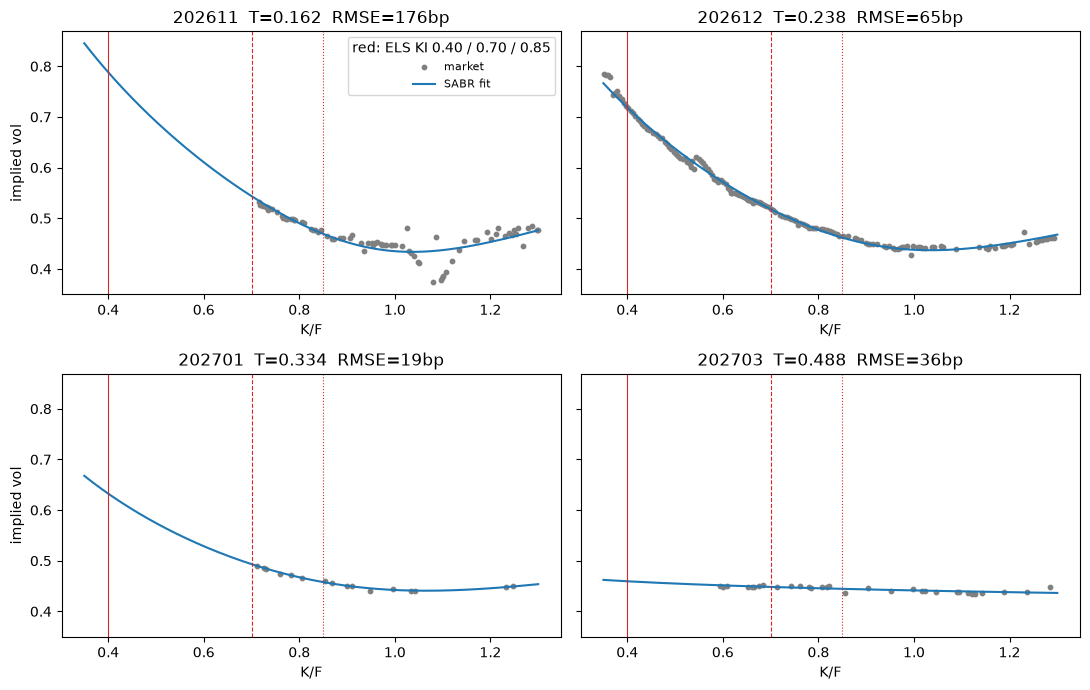

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
kf = np.linspace(0.35, 1.30, 200)
for ax, (_, p) in zip(axes.flat, params.iterrows()):
    g = market[market.expiry == p.expiry]
    ax.scatter(g.kf, g.iv, s=10, color="gray", label="market")
    ax.plot(kf, sabr_vol(1.0, kf, p["T"], p.alpha, p.rho, p.nu), color="C0", label="SABR fit")
    for x, ls in [(0.40, "-"), (0.70, "--"), (0.85, ":")]:
        ax.axvline(x, color="C3", ls=ls, lw=0.8)
    ax.set_title(f"{p.expiry}  T={p['T']:.3f}  RMSE={p.rmse_bp:.0f}bp")
    ax.set_xlabel("K/F")
axes[0, 0].set_ylabel("implied vol"); axes[1, 0].set_ylabel("implied vol")
axes[0, 0].legend(title="red: ELS KI 0.40 / 0.70 / 0.85", fontsize=8)
plt.tight_layout()
fig.savefig(FIG / "smile_fit.png", dpi=130, bbox_inches="tight")
plt.show()

### 3. 연속 곡면과 차익거래

관측 만기 사이는 total variance $w = \sigma^2 T$를 선형 보간합니다. 마지막 관측 만기(2027-03) 이후는 시장 데이터가 없어 가정으로 만듭니다. 3Y slice의 ρ, ν는 가장 유동적인 2026-12에서 가져오고(ν는 $\sqrt{T}$로 줄임), α는 3Y vol이 ELS 투자설명서의 평가 변동성 35.47%가 되도록 맞춥니다.

먼저 SABR slice를 그대로 이어 붙인 곡면을 점검합니다.

In [5]:
k_grid, T_grid = standard_grids()
raw = build_surface(params, "varswap", calendar_floor=False)
cal_raw = check_calendar(raw, k_grid, T_grid)
print(f"calendar 위반 {len(cal_raw)}개")
cal_raw.groupby(["T_from", "T_to"]).K_over_F.agg(["count", "min", "max"]).head()

calendar 위반 154개


,,count,min,max
T_from,T_to,,,
0.32,0.34,3,0.35,0.37
0.34,0.36,21,0.35,0.55
0.36,0.38,21,0.35,0.55
0.38,0.40,21,0.35,0.55
0.40,0.42,21,0.35,0.55


위반 154개는 모두 2027-01 → 2027-03 구간, K/F < 0.56에 있습니다. 두 만기 모두 이 영역에는 데이터가 없어 SABR 식이 외삽한 값입니다. 2027-01의 날개(ν = 0.94)가 거의 평평한 2027-03(ν ≈ 0.07, 가격 32개 중 31개가 체결 없는 KRX 이론정산가)보다 높아서 total variance가 만기에 따라 줄어듭니다.

해결은 관측 slice의 total variance에 하한 $w_i(m) \ge w_{i-1}(m)$을 두는 것입니다. 시장 데이터가 있는 K/F ≥ 0.59에서는 값이 바뀌지 않습니다.

In [6]:
surf = build_surface(params, "varswap")
cal, bf = check_calendar(surf, k_grid, T_grid), check_butterfly(surf, k_grid, T_grid)
print(f"calendar 위반 {len(cal)}개, butterfly 위반 {len(bf)}개")
for _, p in params.iterrows():
    m = market.loc[market.expiry == p.expiry, "kf"].to_numpy()
    assert np.allclose(surf.implied_vol(m * surf.forward(p["T"]), p["T"]), sabr_vol(1.0, m, p["T"], p.alpha, p.rho, p.nu), atol=1e-8)
print("시장 데이터가 있는 행사가에서는 calibration 결과와 일치")

calendar 위반 0개, butterfly 위반 0개
시장 데이터가 있는 행사가에서는 calibration 결과와 일치


### 4. 3Y slice의 기준

35.47%를 3Y ATM vol로 볼지, 3Y variance-swap vol로 볼지 정해야 합니다. 투자설명서는 평가 변동성을 Volatility Surface에서 VIX 방법론(Jiang and Tian, 2005)으로 산출한 값이라고 적고 있습니다. VIX 방법론은 OTM 옵션 가격을 적분한 model-free implied variance이므로 variance-swap vol에 맞췄습니다.

In [7]:
T3 = 3.0
atm_3y, vs_3y = float(surf.implied_vol(surf.forward(T3), T3)), varswap_vol(surf, T3)
pd.DataFrame({"vol": [ELS_FAIR_VOL, atm_3y, vs_3y]}, index=["disclosed ELS vol", "ATM vol (3Y)", "variance-swap vol (3Y)"])

,vol
disclosed ELS vol,0.3547
ATM vol (3Y),0.3328
variance-swap vol (3Y),0.3547


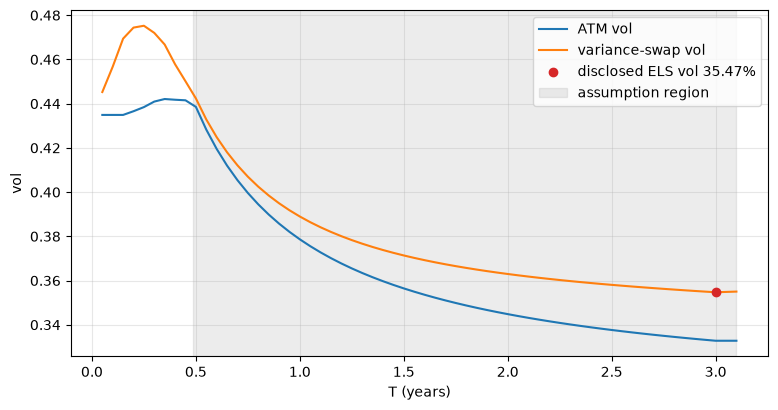

In [8]:
T_ts = np.linspace(0.05, 3.1, 62)
atm_ts = np.array([float(surf.implied_vol(surf.forward(t), t)) for t in T_ts])
vs_ts = np.array([varswap_vol(surf, t) for t in T_ts])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(T_ts, atm_ts, label="ATM vol")
ax.plot(T_ts, vs_ts, label="variance-swap vol")
ax.scatter([3.0], [ELS_FAIR_VOL], color="C3", zorder=5, label="disclosed ELS vol 35.47%")
ax.axvspan(surf.T_last, 3.1, color="gray", alpha=0.15, label="assumption region")
ax.set_xlabel("T (years)"); ax.set_ylabel("vol"); ax.legend(); ax.grid(alpha=0.3)
fig.savefig(FIG / "term_structure.png", dpi=130, bbox_inches="tight")
plt.show()

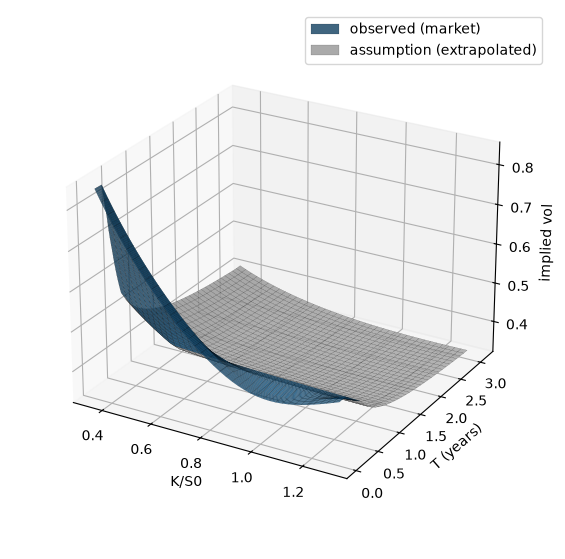

In [9]:
k_axis = np.linspace(0.35, 1.30, 40)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection="3d")
for T_axis, color, label in [(np.linspace(0.02, surf.T_last, 25), "C0", "observed (market)"),
                             (np.linspace(surf.T_last, 3.1, 30), "lightgray", "assumption (extrapolated)")]:
    KK, TT = np.meshgrid(k_axis, T_axis)
    ax.plot_surface(KK, TT, surf.implied_vol(KK * S0, TT), color=color, alpha=0.8, edgecolor="k", linewidth=0.1, label=label)
ax.set_xlabel("K/S0"); ax.set_ylabel("T (years)"); ax.set_zlabel("implied vol")
ax.view_init(elev=25, azim=-60); ax.set_box_aspect(None, zoom=0.9); ax.legend()
fig.savefig(FIG / "surface_3d.png", dpi=130, bbox_inches="tight")
plt.show()